In [ ]:
#the aim of this project is to view protein structures and to analyse them
#ill compute:
# 1) distance matrices between residues - entry (i,j) is distance between residues i and j. - comparing predicted to experimetnal matrices gives us confidence metrics
# 2) radius of gyration - scalar measure of how compact a protein is, helps us track folding, normalise compactness, detecs bad predictions, 
# 3) secondary structure statistics - sequence dependant, easier to predict than full 3D structure, compare protein classes, sanity check


In [57]:
#Step 1 - Load and inspect a PDB file . 1) Load a structure, 2)print how many residues it has, 3) extract c_alpha positions

from Bio.PDB.PDBParser import PDBParser as pdb
from Bio.PDB.Polypeptide import is_aa
import numpy as np

parser = pdb()

structure = parser.get_structure('myoglobin', '1MBA.pdb')

residues = list(structure.get_residues())

n_residues = sum(
    1
    for residue in residues
    if is_aa(residue)==True
)




c_alphas_pos = []
for residue in residues:
    if is_aa(residue)==True:
        ca = residue["CA"]

        position = ca.get_coord()
        c_alphas_pos.append(position)

print(n_residues)

print(c_alphas_pos)






146
[array([-69.69 , -51.684, -22.866], dtype=float32), array([-67.203, -53.695, -21.026], dtype=float32), array([-67.974, -55.637, -17.912], dtype=float32), array([-66.824, -54.376, -14.516], dtype=float32), array([-64.172, -57.048, -14.542], dtype=float32), array([-62.931, -56.125, -18.009], dtype=float32), array([-63.008, -52.47 , -17.204], dtype=float32), array([-60.887, -52.95 , -14.076], dtype=float32), array([-58.221, -54.81 , -16.183], dtype=float32), array([-58.103, -51.995, -18.664], dtype=float32), array([-57.775, -49.467, -15.823], dtype=float32), array([-55.053, -51.479, -14.159], dtype=float32), array([-52.998, -51.62 , -17.393], dtype=float32), array([-53.585, -47.923, -18.079], dtype=float32), array([-52.489, -46.602, -14.708], dtype=float32), array([-48.712, -46.95 , -15.262], dtype=float32), array([-49.159, -45.301, -18.699], dtype=float32), array([-51.244, -42.401, -17.478], dtype=float32), array([-48.747, -41.949, -14.497], dtype=float32), array([-46.558, -40.098, -

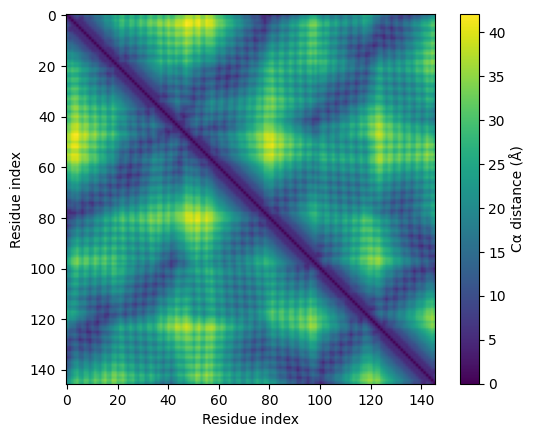

In [ ]:
#Step 2 - Compute a distance matrix - d_ij = | r_i - r_j |,   plot heatmap and look for domains

D = []

for c_i in c_alphas_pos:
    D.append([np.linalg.norm(c_i - c_j) for c_j in c_alphas_pos])
    
D = np.array(D)

import matplotlib.pyplot as plt

plt.imshow(D, cmap="viridis")
plt.colorbar(label="Cα distance (Å)")
plt.xlabel("Residue index")
plt.ylabel("Residue index")
plt.show()

#AI produces a distance matrix

In [ ]:
#Step 3 - Radius of gyration

In [ ]:
#step 4 - Secondary structure statistics

In [ ]:
#step 5 - visualise contacts